# Load Libraries

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, r2_score, mean_absolute_error

warnings.filterwarnings('ignore') 

# Load Dataset

In [72]:
# Laki - Laki Genap : Dataset C
dataset = pd.read_csv('../Dataset/data_1C.csv')
dataset.head()

,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,y
0,0,29,technician,single,basic.9y,no,yes,no,cellular,nov,wed,648.0,1,999,0,nonexistent,no
1,1,31,admin.,single,university.degree,no,no,no,cellular,aug,wed,295.0,1,999,0,nonexistent,no
2,2,27,blue-collar,single,basic.9y,no,yes,no,telephone,jul,mon,236.0,2,999,0,nonexistent,no
3,3,30,services,married,unknown,no,no,no,telephone,may,wed,143.0,3,999,0,nonexistent,no
4,4,32,technician,married,university.degree,no,no,no,cellular,aug,thu,155.0,1,999,0,nonexistent,no


## Drop Useless Columns

- Unnamed: 0 - Index Column
- month, day_of_week -> same as duration

We Will assume that unknown values are not missing values and will be treated as a separate category

In [73]:
dataset = dataset.drop(columns=['Unnamed: 0', 'month', 'day_of_week'], axis=1)

# EDA

## Data Description

In [74]:
dataset.describe()

,age,duration,campaign,pdays,previous
count,8237.000000,8222.000000,8237.000000,8237.000000,8237.000000
mean,40.000486,260.189370,2.555299,962.352434,0.172393
std,10.331078,254.942835,2.663180,187.221927,0.481973
min,17.000000,0.000000,1.000000,0.000000,0.000000
25%,32.000000,103.000000,1.000000,999.000000,0.000000
50%,38.000000,183.000000,2.000000,999.000000,0.000000
75%,47.000000,324.000000,3.000000,999.000000,0.000000
max,98.000000,3284.000000,43.000000,999.000000,6.000000


The data is not normally distributed, this can be seen from the diffrence between mean and 50% percentile (median). The data also contain some large values, thus we will need to scale the data.

## Data Types

In [75]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8237 entries, 0 to 8236
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        8237 non-null   int64  
 1   job        8227 non-null   object 
 2   marital    8237 non-null   object 
 3   education  8237 non-null   object 
 4   default    8237 non-null   object 
 5   housing    8237 non-null   object 
 6   loan       8237 non-null   object 
 7   contact    8237 non-null   object 
 8   duration   8222 non-null   float64
 9   campaign   8237 non-null   int64  
 10  pdays      8237 non-null   int64  
 11  previous   8237 non-null   int64  
 12  poutcome   8237 non-null   object 
 13  y          8237 non-null   object 
dtypes: float64(1), int64(4), object(9)
memory usage: 901.1+ KB


There's 5 numerical columns and 11 categorical column in the dataset.

## Missing Values

In [76]:
dataset.isnull().sum()

age           0
job          10
marital       0
education     0
default       0
housing       0
loan          0
contact       0
duration     15
campaign      0
pdays         0
previous      0
poutcome      0
y             0
dtype: int64

There's a few missing value in the dataset, we will need to fill them.

## Data Correlation

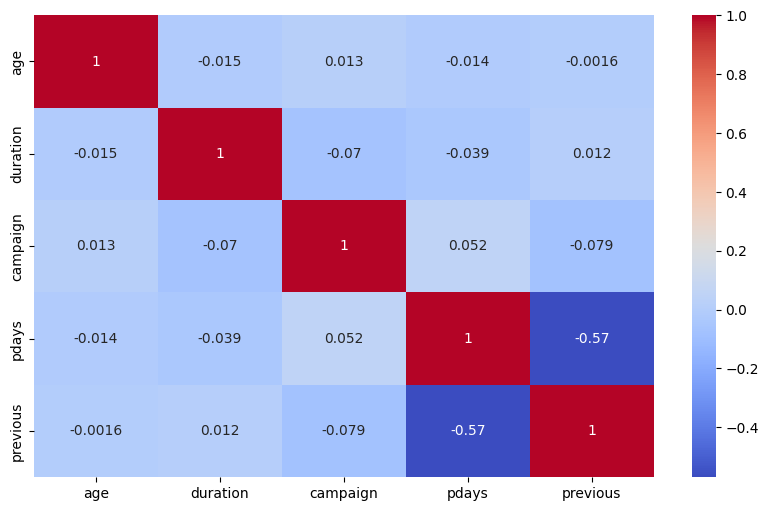

In [77]:
numerical_data = dataset.select_dtypes(include=[np.number])

# correlation matrix
corr = numerical_data.corr()

# plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

pdays and previous columns are highly inversely correlated, we will need to drop one of them. (pdays)

## Data Distribution

In [78]:
def plot_distribution(data) :
    fig = plt.figure(figsize=(10, 6))
    plt.title(f'Distribution of {data.name}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    if data.dtype == np.float64 or data.dtype == np.int64 :
        plt.hist(data, bins=20, edgecolor='black')
    else :
        data.value_counts().plot(kind='bar')
    plt.show()

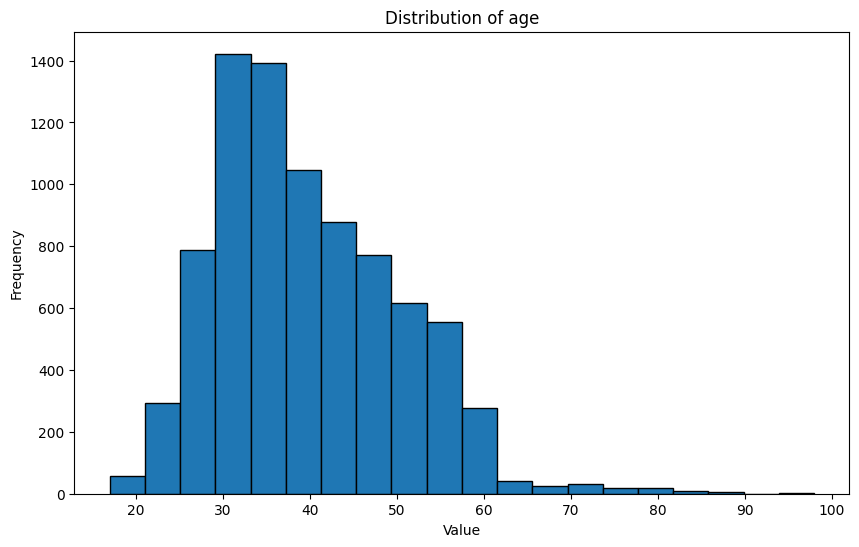

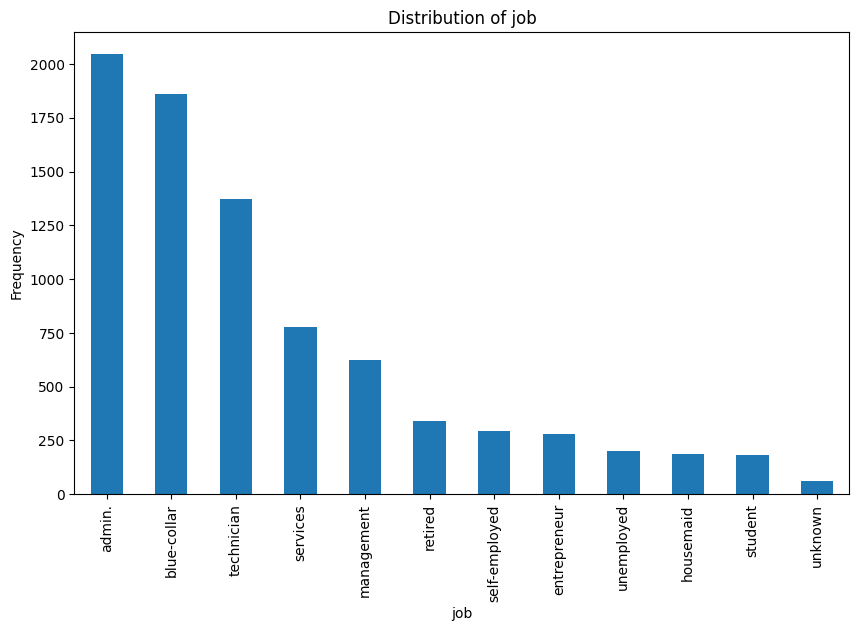

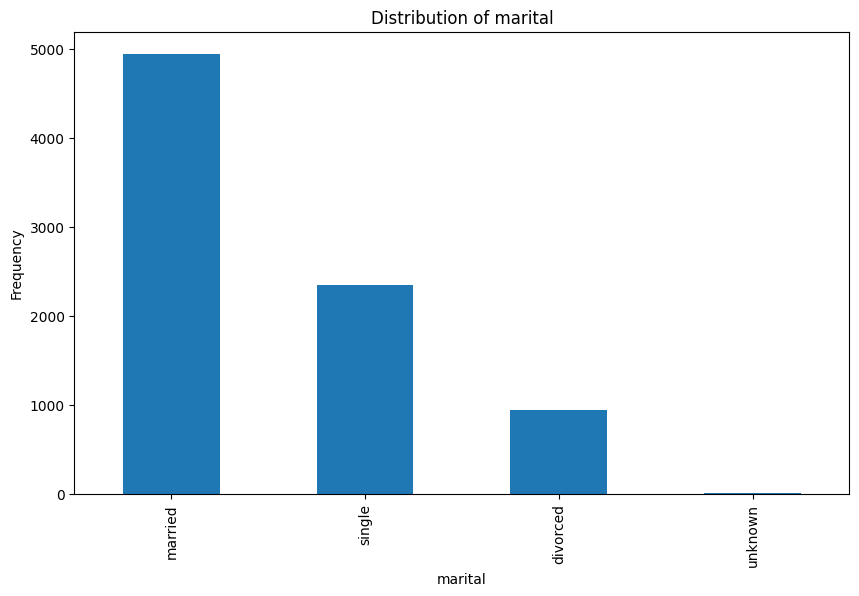

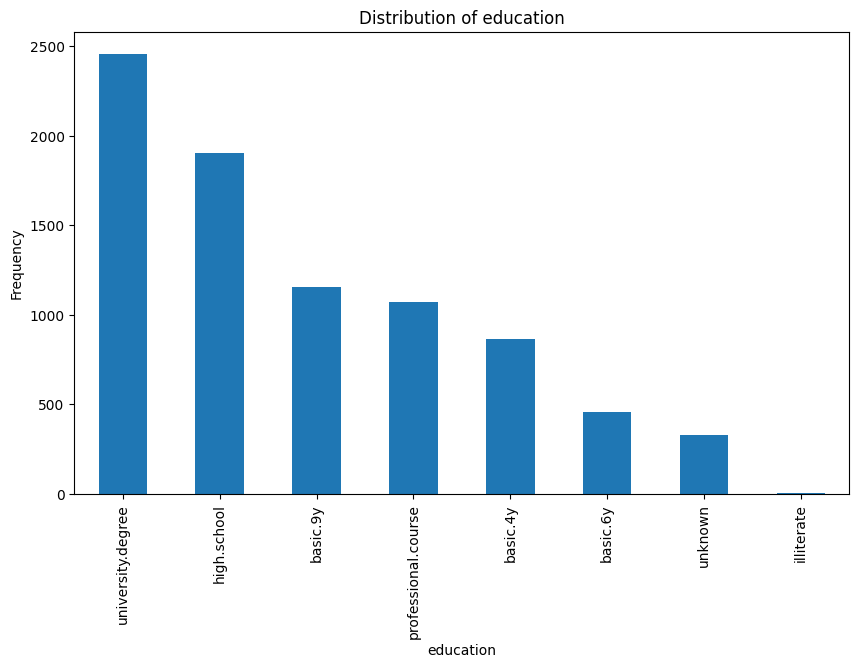

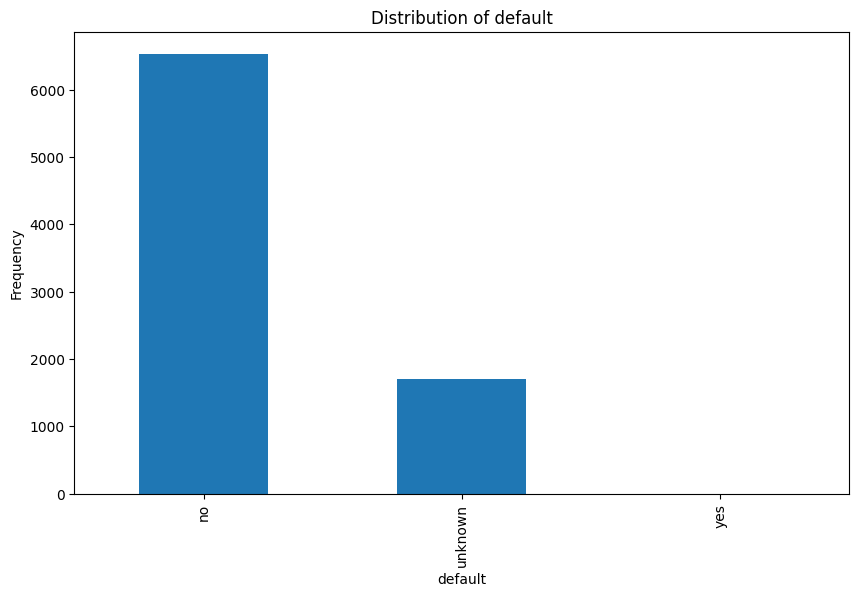

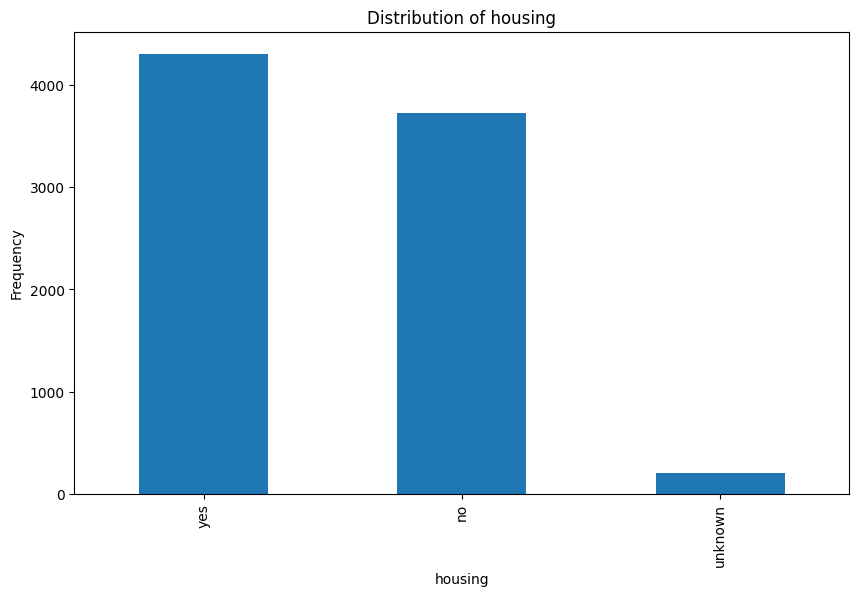

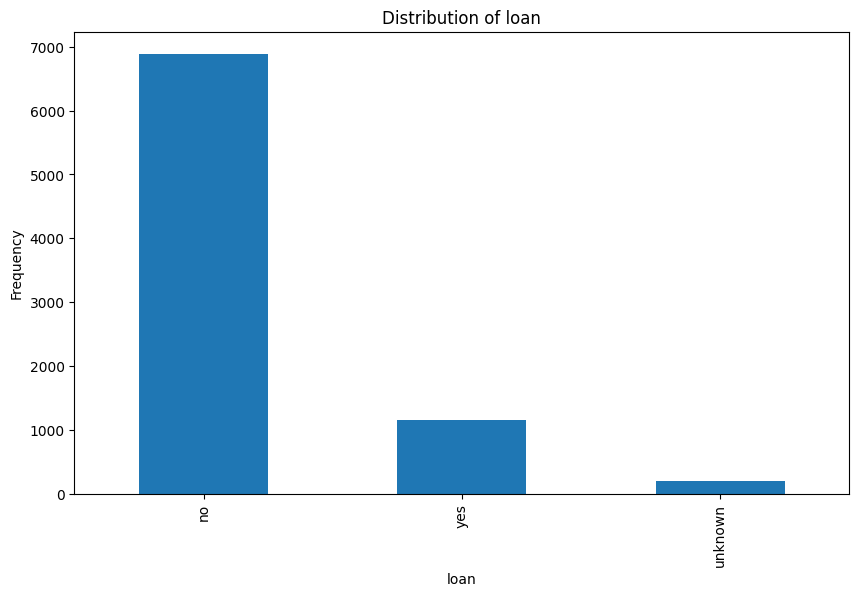

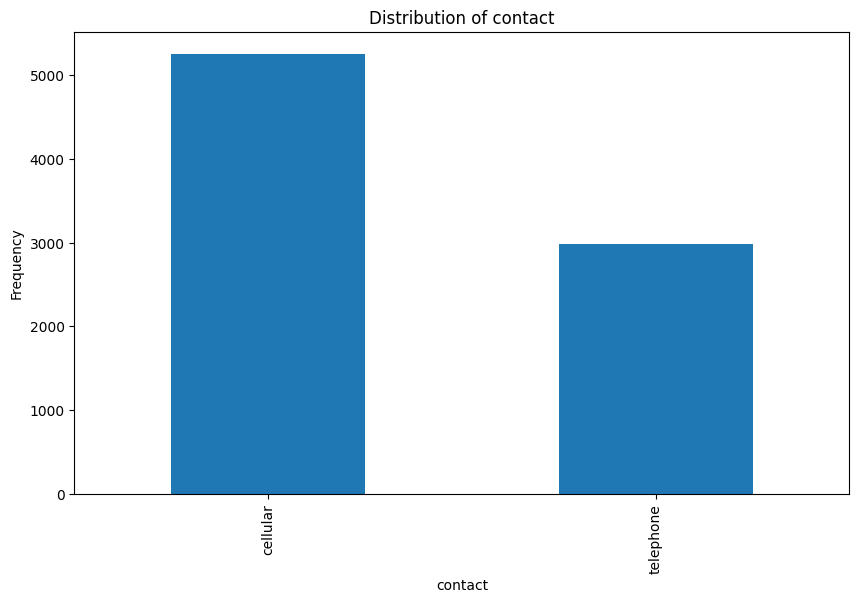

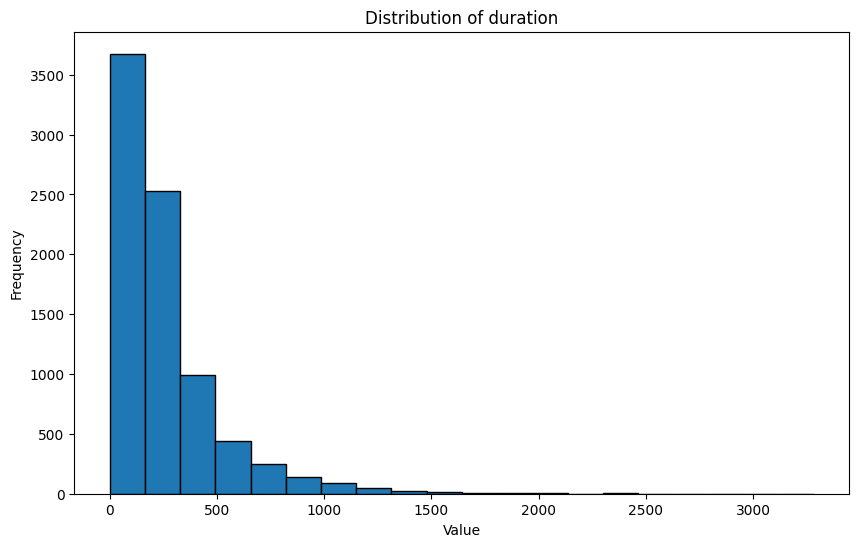

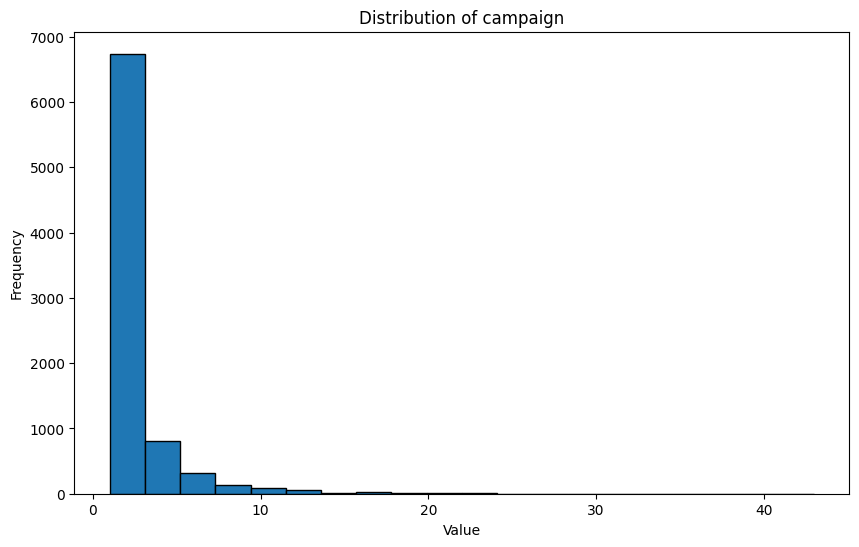

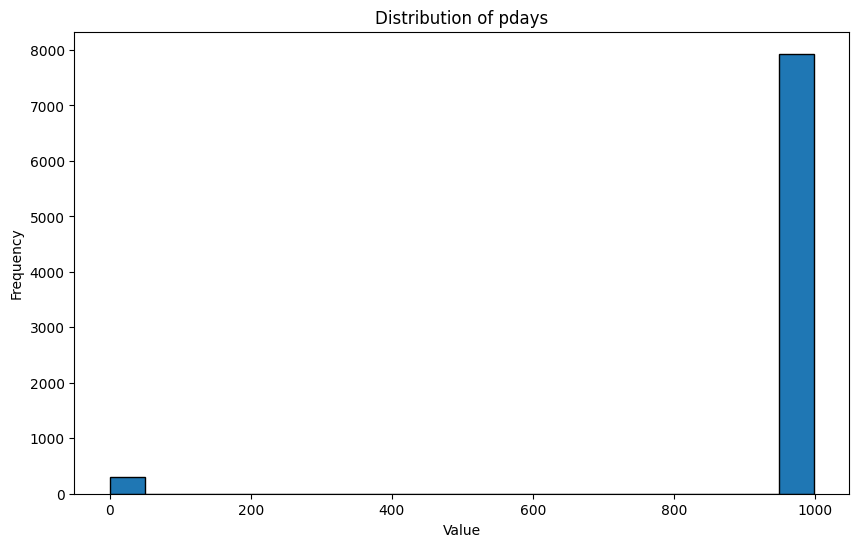

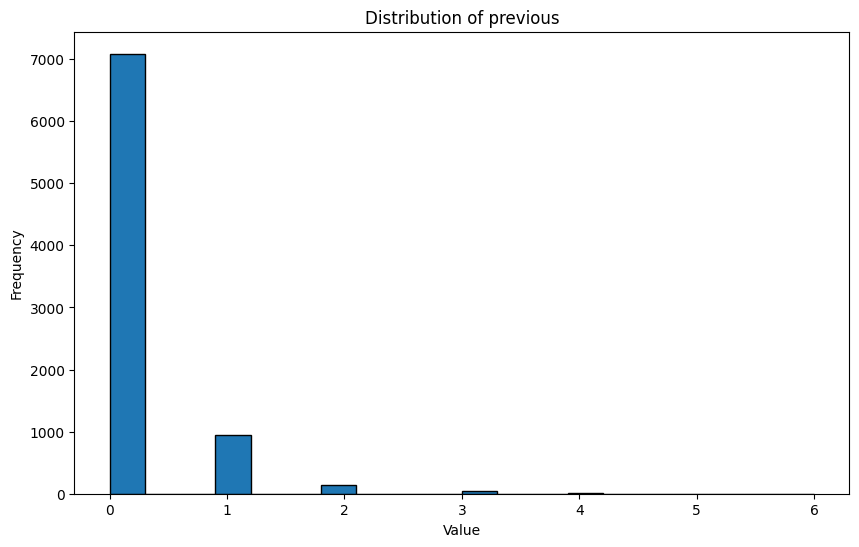

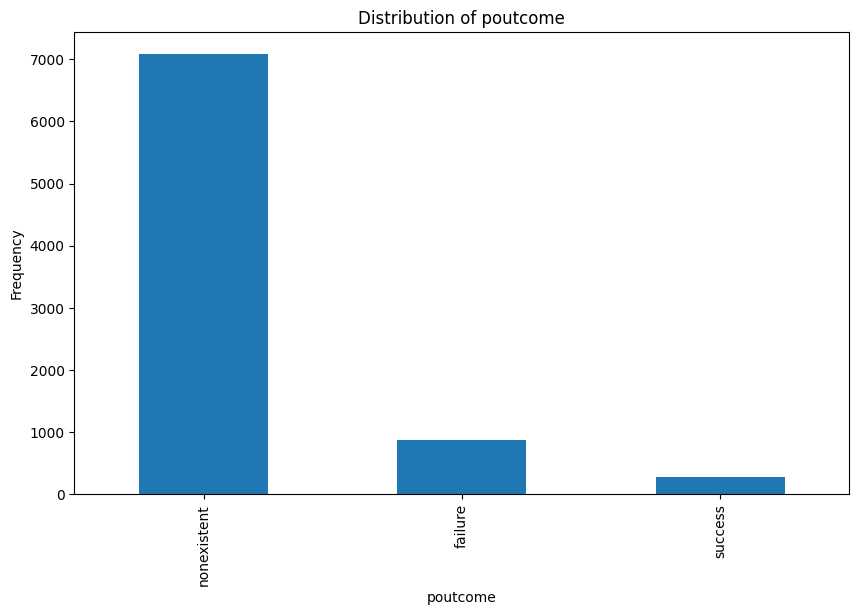

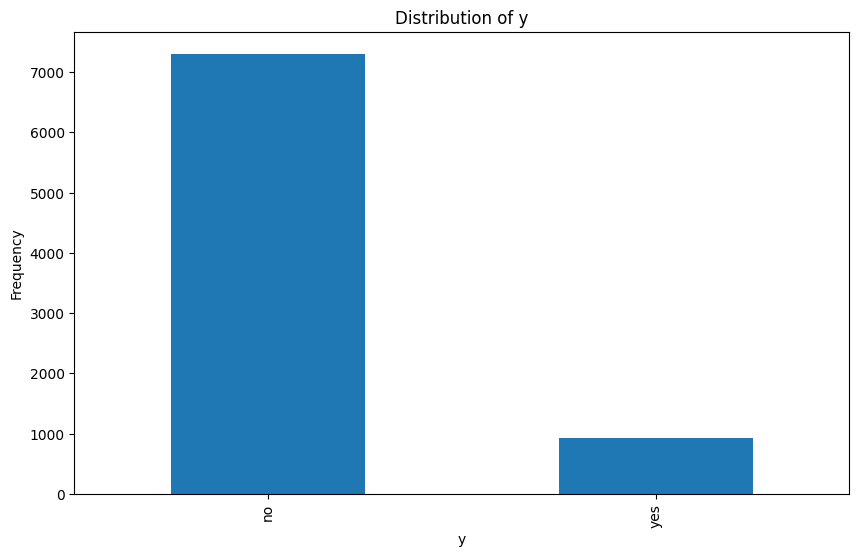

In [79]:
for column in dataset.columns:
    plot_distribution(dataset[column])  

From the graph above we can see that the data is highly imabalanced and not normally distributed. We will need to scale the data but we wont fix the imbalance because it could lead to overfitting.

# Data Preprocessing

## Drop  Highly Correlated Columns

Dropping highly correlated columns to avoid multicollinearity.

In [80]:
dataset = dataset.drop(columns=['pdays'], axis=1)

## Split Dataset

In [81]:
X, y = dataset.drop(columns=['y'], axis=1), dataset['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Fill Missing Values

Filling Missing Values with the mode of the column for categorical columns and mean for numerical columns.

In [82]:
X_train['job'].fillna(X_train['job'].mode()[0], inplace=True)
X_train['duration'].fillna(X_train['duration'].mean(), inplace=True)

In [83]:
X_test['job'].fillna(X_test['job'].mode()[0], inplace=True)
X_test['duration'].fillna(X_test['duration'].mean(), inplace=True)

## Scale Data

Scale the data so that it fits the normal distribution.

In [84]:
scaler = StandardScaler()

X_train_numercial = X_train.select_dtypes(include=[np.number])
X_test_numerical = X_test.select_dtypes(include=[np.number])

scaler.fit(X_train_numercial)

X_train_numercial = scaler.transform(X_train_numercial)
X_test_numerical = scaler.transform(X_test_numerical)

In [85]:
X_train_numercial = pd.DataFrame(X_train_numercial, columns=X_train.select_dtypes(include=[np.number]).columns)
X_test_numerical = pd.DataFrame(X_test_numerical, columns=X_test.select_dtypes(include=[np.number]).columns)

X_train_numercial.reset_index(drop=True, inplace=True)
X_test_numerical.reset_index(drop=True, inplace=True)

## Encode Categorical Columns

Encode the categorical columns so that they can be used in the model.

In [86]:
encoder = OneHotEncoder(handle_unknown='infrequent_if_exist')

X_train_categorical = X_train.select_dtypes(include=[object])
X_test_categorical = X_test.select_dtypes(include=[object])

encoder.fit(X_train_categorical)

X_train_categorical = encoder.transform(X_train_categorical).toarray()
X_test_categorical = encoder.transform(X_test_categorical).toarray()

In [87]:
X_train_categorical = pd.DataFrame(X_train_categorical, columns=encoder.get_feature_names_out())
X_test_categorical = pd.DataFrame(X_test_categorical, columns=encoder.get_feature_names_out())

X_train_categorical.reset_index(drop=True, inplace=True)
X_test_categorical.reset_index(drop=True, inplace=True)

## Concatenate Data

In [88]:
X_train = pd.concat([X_train_numercial, X_train_categorical], axis=1)
X_test = pd.concat([X_test_numerical, X_test_categorical], axis=1)

# Model Selection

Train multiple model to find the best one for the dataset.

## Logistic Regression

In [89]:
logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)

LogisticRegression()

### Evaluation

In [90]:
predictions = logistic_regression.predict(X_test)

print(classification_report(y_test, predictions, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.92      0.98      0.95      1471
         Yes       0.64      0.31      0.42       177

    accuracy                           0.91      1648
   macro avg       0.78      0.64      0.68      1648
weighted avg       0.89      0.91      0.89      1648



## Decision Tree

In [91]:
DecisionTree = DecisionTreeClassifier()
DecisionTree.fit(X_train, y_train)

DecisionTreeClassifier()

In [92]:
predictions = DecisionTree.predict(X_test)

print(classification_report(y_test, predictions, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.93      0.91      0.92      1471
         Yes       0.35      0.41      0.38       177

    accuracy                           0.85      1648
   macro avg       0.64      0.66      0.65      1648
weighted avg       0.87      0.85      0.86      1648



# Conclusion

From the 2 model above, we can see that Logistic Regression is the best model for this dataset. THis can be seen from the f1 score of the yes class. We will use F1 score because the data is imbalanced and we want to see the model's performance on the positive class.

## Save Model

In [93]:
pickle.dump(logistic_regression, open('logistic_regression_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(encoder, open('encoder.pkl', 'wb'))